# Identification of handwritten digits

Steps:

1. Loading data
2. Dimensionality reduction
3. Classification


## Loading and visualizing the digits data


In [3]:
from sklearn.datasets import load_digits

digits = load_digits()
digits.images.shape

(1797, 8, 8)

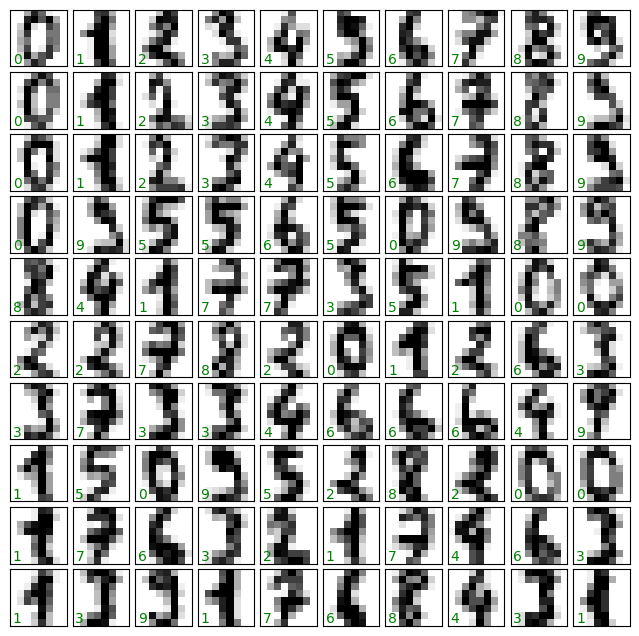

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    10,
    10,
    figsize=(8, 8),
    subplot_kw={"xticks": [], "yticks": []},
    gridspec_kw=dict(hspace=0.1, wspace=0.1),
)
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="binary", interpolation="nearest")
    ax.text(0.05, 0.05, str(digits.target[i]), transform=ax.transAxes, color="green")

In [ ]:
X = digits.data  # each pixel in the image as a feature. 8x8 = 64 features
y = digits.target
X.shape, y.shape

((1797, 64), (1797,))

## Unsupervised learning: Dimensionality reduction


In [6]:
from sklearn.manifold import Isomap

iso = Isomap(n_components=2)
iso.fit(X)
y_projected = iso.transform(X)
y_projected.shape

/Users/riteshraj/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/riteshraj/anaconda3/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 2)

/var/folders/5l/zqn8_gf96l93zx4xczst_5q80000gn/T/ipykernel_88660/1867395019.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap("tab10", 10),


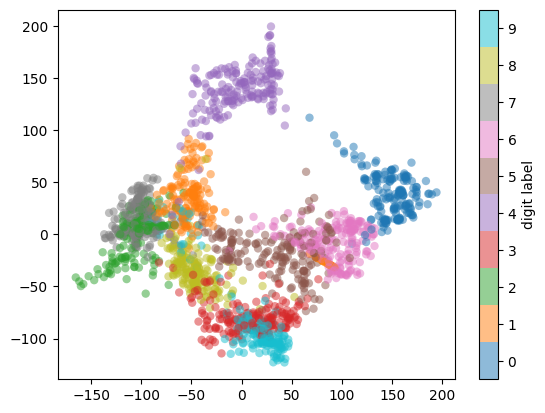

In [11]:
plt.scatter(
    y_projected[:, 0],
    y_projected[:, 1],
    c=y,
    edgecolor="none",
    alpha=0.5,
    cmap=plt.cm.get_cmap("tab10", 10),
)
plt.colorbar(label="digit label", ticks=range(10))
plt.clim(-0.5, 9.5)

## Classification on digits

We are taking classification approach because, from the above image, we can conclude that different groups are well separated in 2D space


In [13]:
from sklearn.model_selection import train_test_split


Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state=0)

In [14]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(Xtrain, ytrain)
y_model = model.predict(Xtest)

In [15]:
from sklearn.metrics import accuracy_score

accuracy_score(ytest, y_model)

0.8333333333333334

Text(110.44999999999997, 0.5, 'true value')

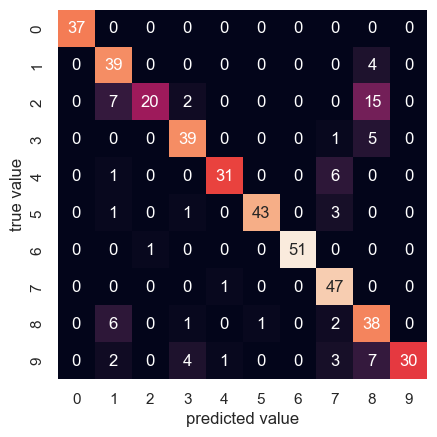

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.set_theme()

mat = confusion_matrix(ytest, y_model)
sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel("predicted value")
plt.ylabel("true value")

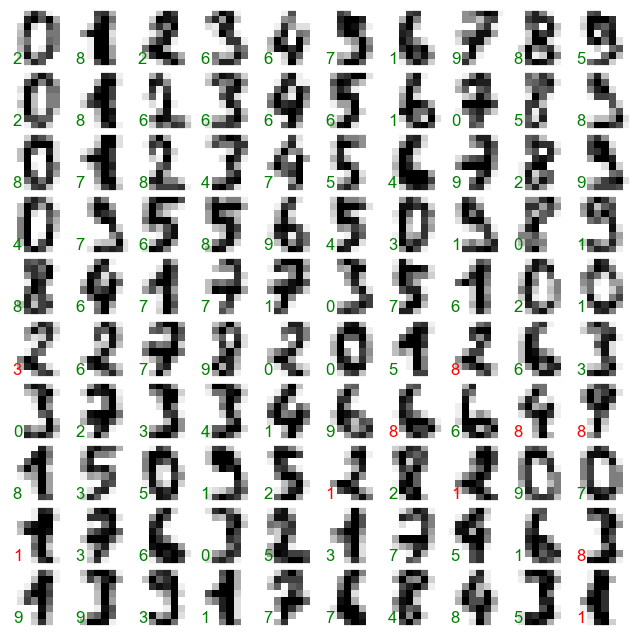

In [18]:
fig, axes = plt.subplots(
    10,
    10,
    figsize=(8, 8),
    subplot_kw={"xticks": [], "yticks": []},
    gridspec_kw=dict(hspace=0.1, wspace=0.1),
)
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="binary", interpolation="nearest")
    ax.text(
        0.05,
        0.05,
        str(y_model[i]),
        transform=ax.transAxes,
        color="green" if (ytest[i] == y_model[i]) else "red",
    )